# 01 — Train ResNet-18 (multi-task)
Trains a ResNet-18 backbone with two heads (8-class classification + 2-dim valence/arousal). Saves best checkpoint and logs.


In [1]:
# Add project to sys.path and show CUDA status
import sys
from pathlib import Path
ROOT = Path().resolve()
if (ROOT/'src').exists():
    sys.path.append(str(ROOT))
elif (ROOT.parent/'src').exists():
    sys.path.append(str(ROOT.parent))

import platform
print("Python:", platform.python_version())

try:
    import torch
    print("CUDA available:", torch.cuda.is_available())
    print("Torch build CUDA:", torch.version.cuda)
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
except Exception as e:
    print("Torch not installed yet:", e)


Python: 3.10.10
CUDA available: True
Torch build CUDA: 12.1
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
#calling script
import subprocess
cmd = [
    'python', 'scripts/train.py',
    '--backbone', 'resnet18',
    '--epochs', '15',
    '--batch-size', '32',
    '--lambda-va', '0.5',
    '--pretrained',
    '--amp'
]
print('Running:', ' '.join(cmd))
ret = subprocess.run(cmd)
print('Return code:', ret.returncode)


Running: python scripts/train.py --backbone resnet18 --epochs 15 --batch-size 32 --lambda-va 0.5 --pretrained --amp
Return code: 2


Project ROOT: c:\Users\moizs\Desktop\Deep_Assignment_1
ckpt exists?  True → c:\Users\moizs\Desktop\Deep_Assignment_1\outputs\checkpoints\resnet18_best.pt
eval_script?  True → c:\Users\moizs\Desktop\Deep_Assignment_1\scripts\eval_report.py
Running: c:\Users\moizs\AppData\Local\Programs\Python\Python310\python.exe c:\Users\moizs\Desktop\Deep_Assignment_1\scripts\eval_report.py --backbone resnet18 --ckpt c:\Users\moizs\Desktop\Deep_Assignment_1\outputs\checkpoints\resnet18_best.pt
Return code: 0
--- stdout ---
 Saved figs + summary to: reports\figs\resnet18

--- stderr ---
 


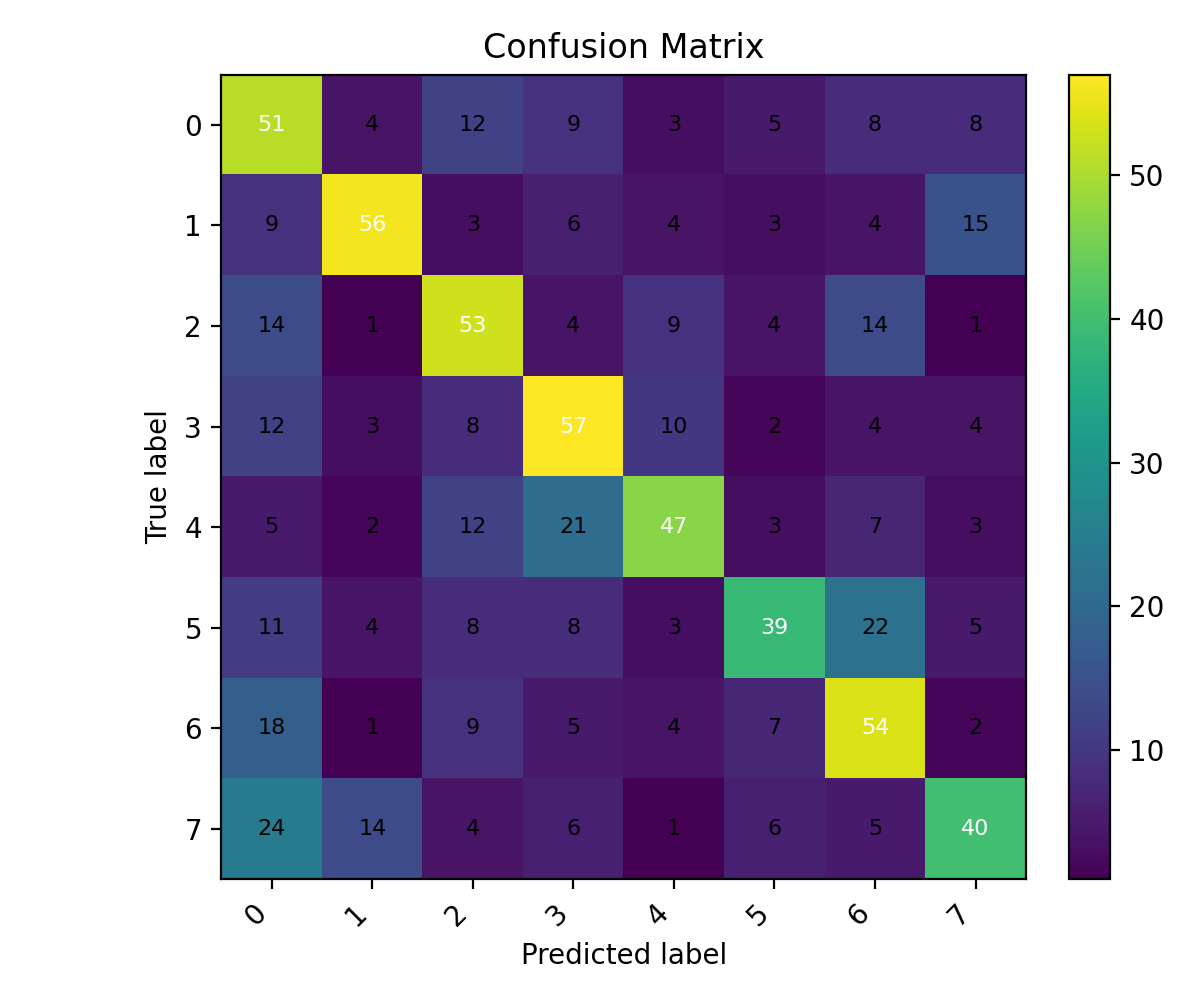

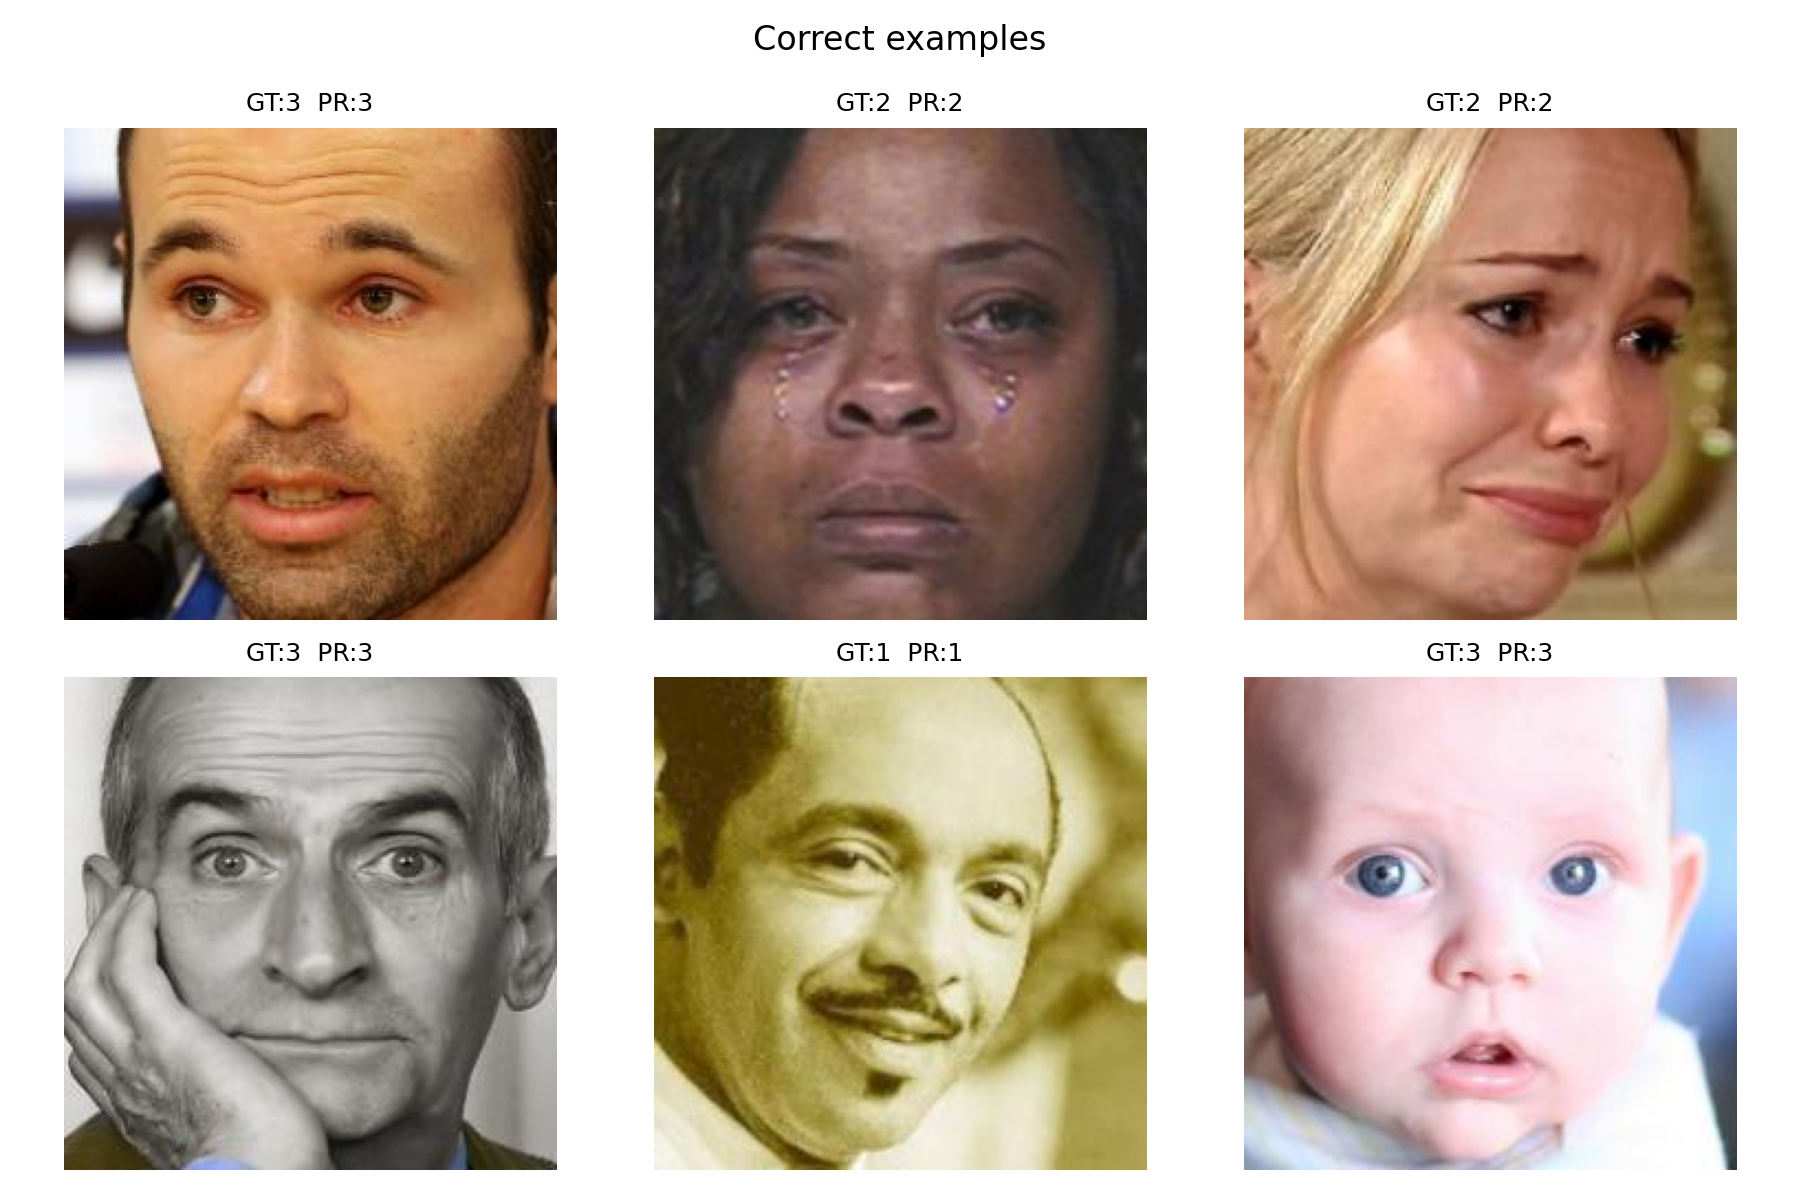

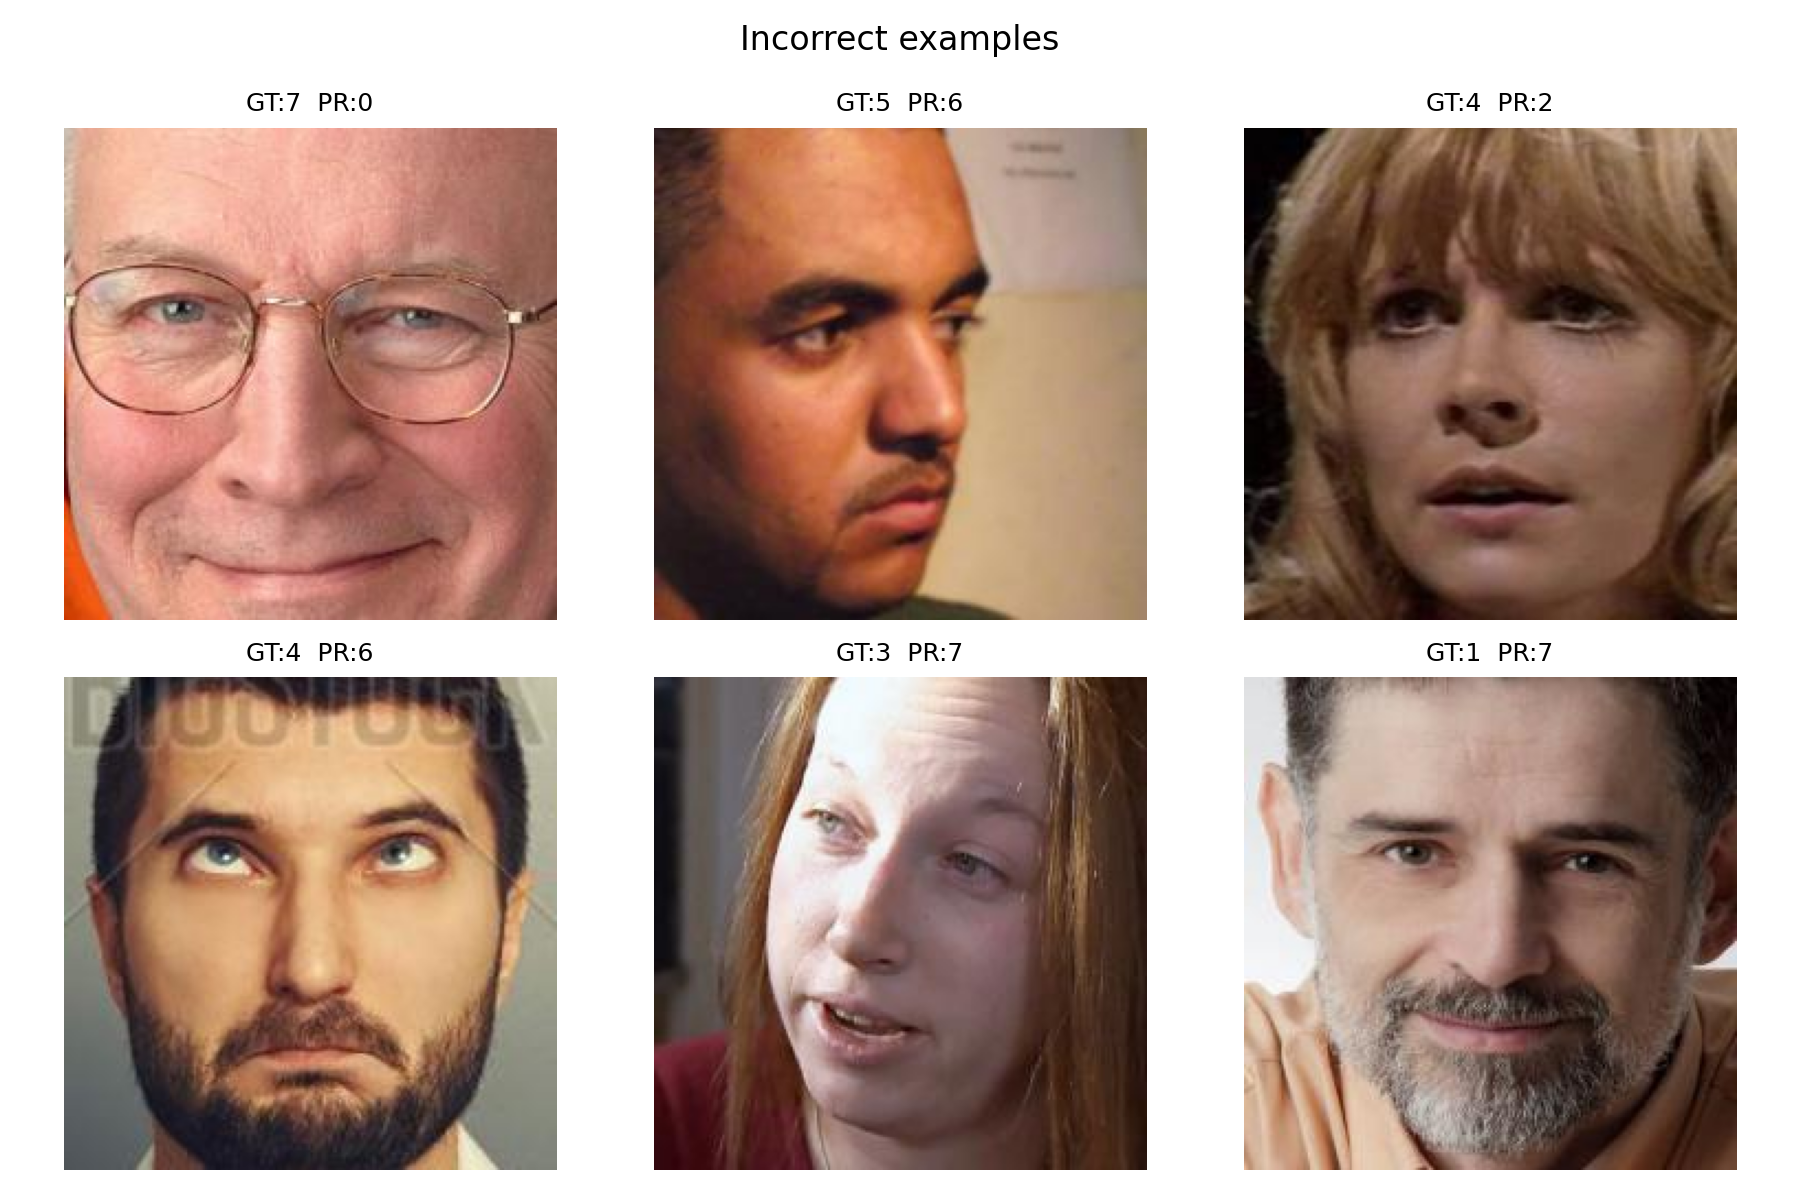

In [5]:
# Run eval_report for ResNet-18 from a notebook, robustly (Windows-friendly)

from pathlib import Path
import os, sys, subprocess

# 1) Find the project root (folder that has both 'src/' and 'scripts/')
ROOT = Path.cwd()
for cand in [ROOT, ROOT.parent, ROOT.parent.parent]:
    if (cand/'src').exists() and (cand/'scripts').exists():
        ROOT = cand
        break
print("Project ROOT:", ROOT)

# 2) Build absolute paths
ckpt     = ROOT / 'outputs' / 'checkpoints' / 'resnet18_best.pt'
eval_py  = ROOT / 'scripts' / 'eval_report.py'

print("ckpt exists? ", ckpt.exists(), "→", ckpt)
print("eval_script? ", eval_py.exists(), "→", eval_py)

# 3) Ensure Python can import your src/ (PYTHONPATH)
env = os.environ.copy()
env['PYTHONPATH'] = str(ROOT) + os.pathsep + env.get('PYTHONPATH', '')

# 4) Run the eval script from the project root and capture output
cmd = [sys.executable, str(eval_py), '--backbone', 'resnet18', '--ckpt', str(ckpt)]
print("Running:", " ".join(cmd))

ret = subprocess.run(cmd, cwd=str(ROOT), env=env, capture_output=True, text=True)
print("Return code:", ret.returncode)
print("--- stdout ---\n", ret.stdout)
print("--- stderr ---\n", ret.stderr)

# Optional: display a couple of generated figures inline
from IPython.display import Image, display
out_dir = ROOT / 'reports' / 'figs' / 'resnet18'
if out_dir.exists():
    for f in ['confusion_matrix.png', 'examples_correct.png', 'examples_incorrect.png']:
        p = out_dir / f
        if p.exists(): 
            display(Image(filename=str(p)))


Project ROOT: c:\Users\moizs\Desktop\Deep_Assignment_1
ckpt exists: True → c:\Users\moizs\Desktop\Deep_Assignment_1\outputs\checkpoints\resnet18_best.pt
eval exists: True → c:\Users\moizs\Desktop\Deep_Assignment_1\scripts\eval_report.py
Running: c:\Users\moizs\AppData\Local\Programs\Python\Python310\python.exe c:\Users\moizs\Desktop\Deep_Assignment_1\scripts\eval_report.py --backbone resnet18 --ckpt c:\Users\moizs\Desktop\Deep_Assignment_1\outputs\checkpoints\resnet18_best.pt
Return code: 0
--- stdout ---
 Saved figs + summary to: reports\figs\resnet18

Loaded summary from: c:\Users\moizs\Desktop\Deep_Assignment_1\reports\figs\resnet18\summary.json
{
  "backbone": "resnet18",
  "cls_acc": 0.49625,
  "cls_f1_macro": 0.4980149409947735,
  "cls_kappa": 0.42428571428571427,
  "cls_conf_mat": [
    [
      51,
      4,
      12,
      9,
      3,
      5,
      8,
      8
    ],
    [
      9,
      56,
      3,
      6,
      4,
      3,
      4,
      15
    ],
    [
      14,
      1,
  

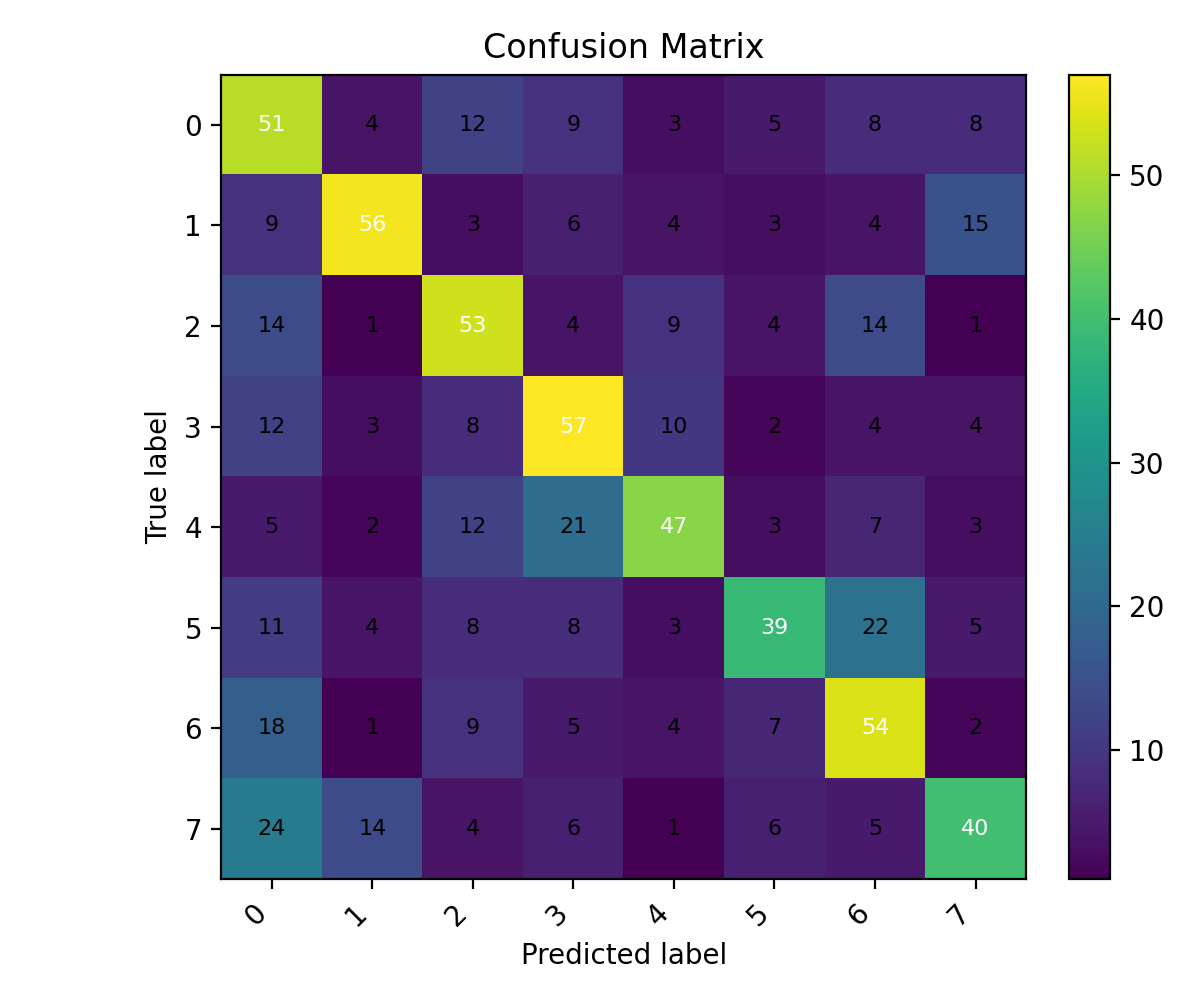

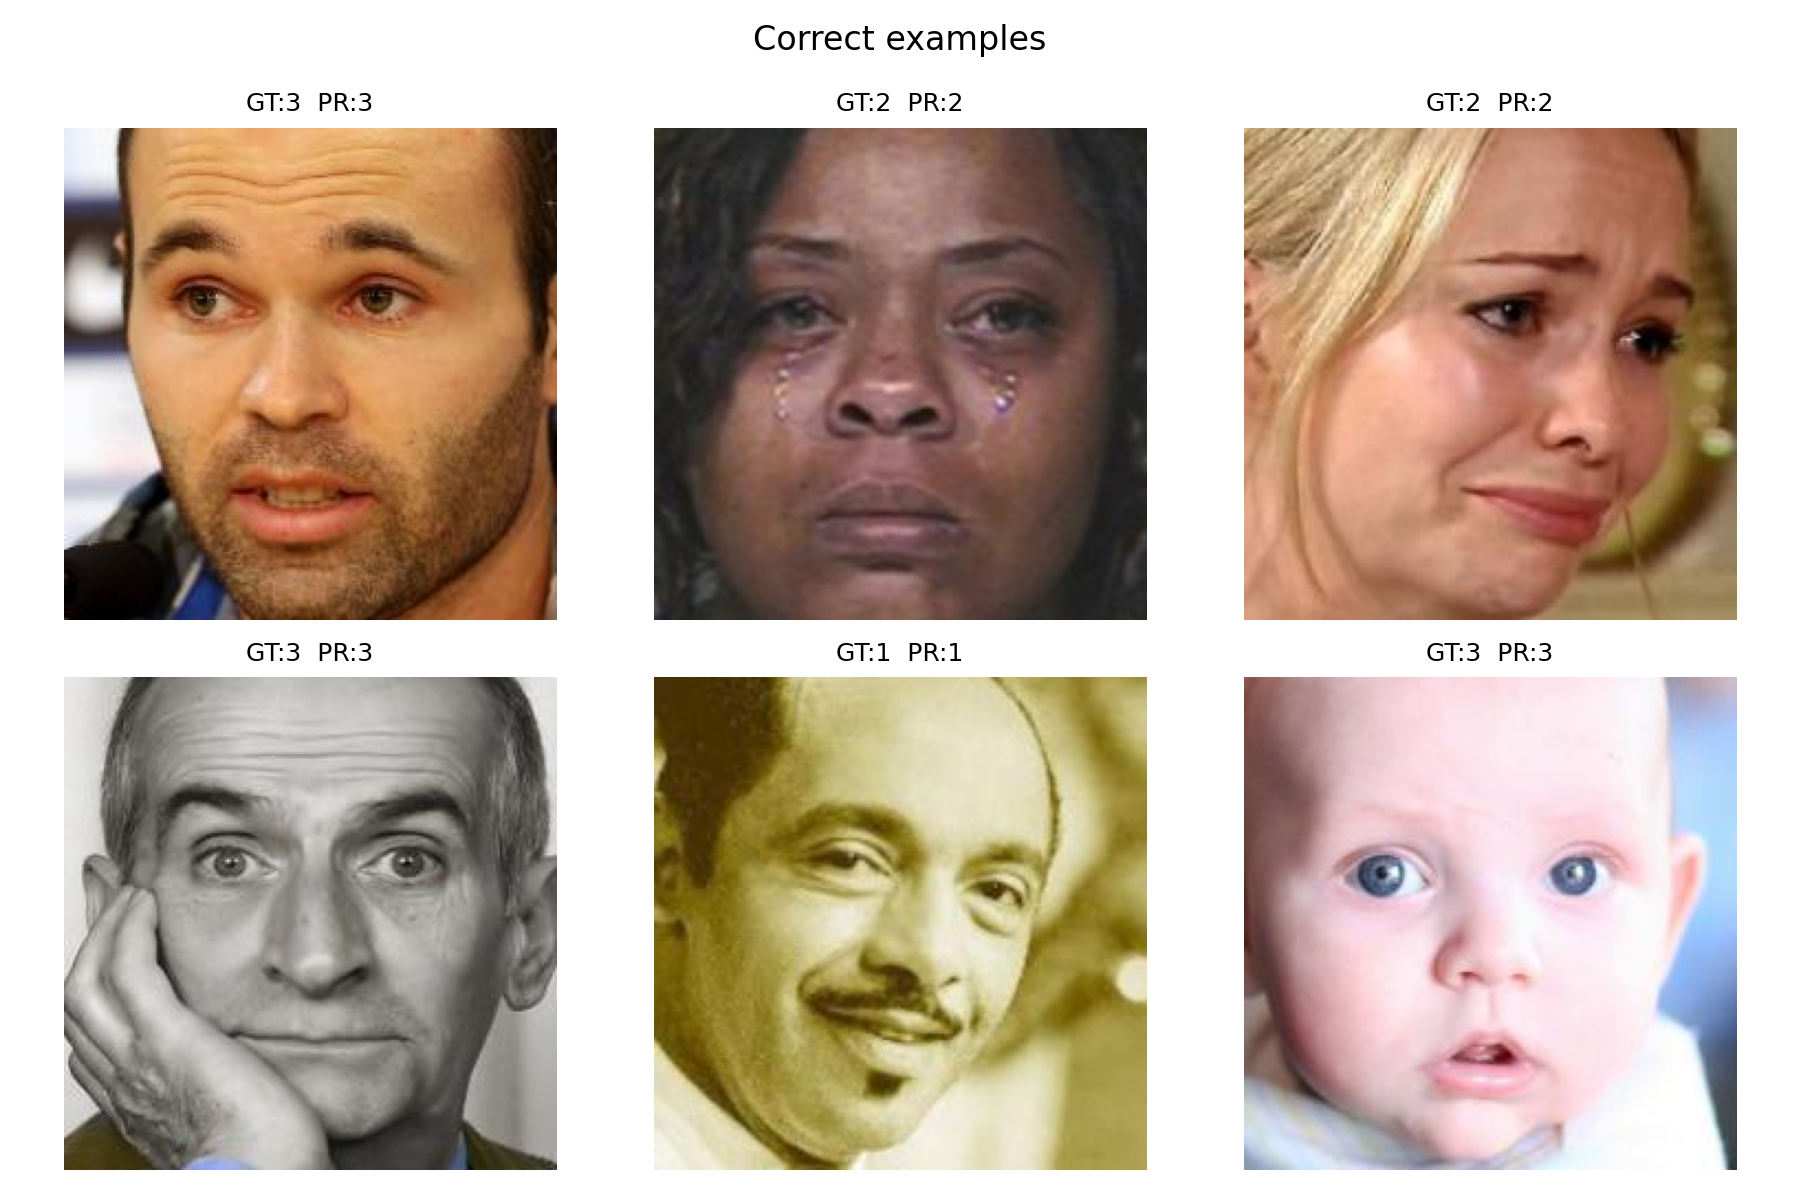

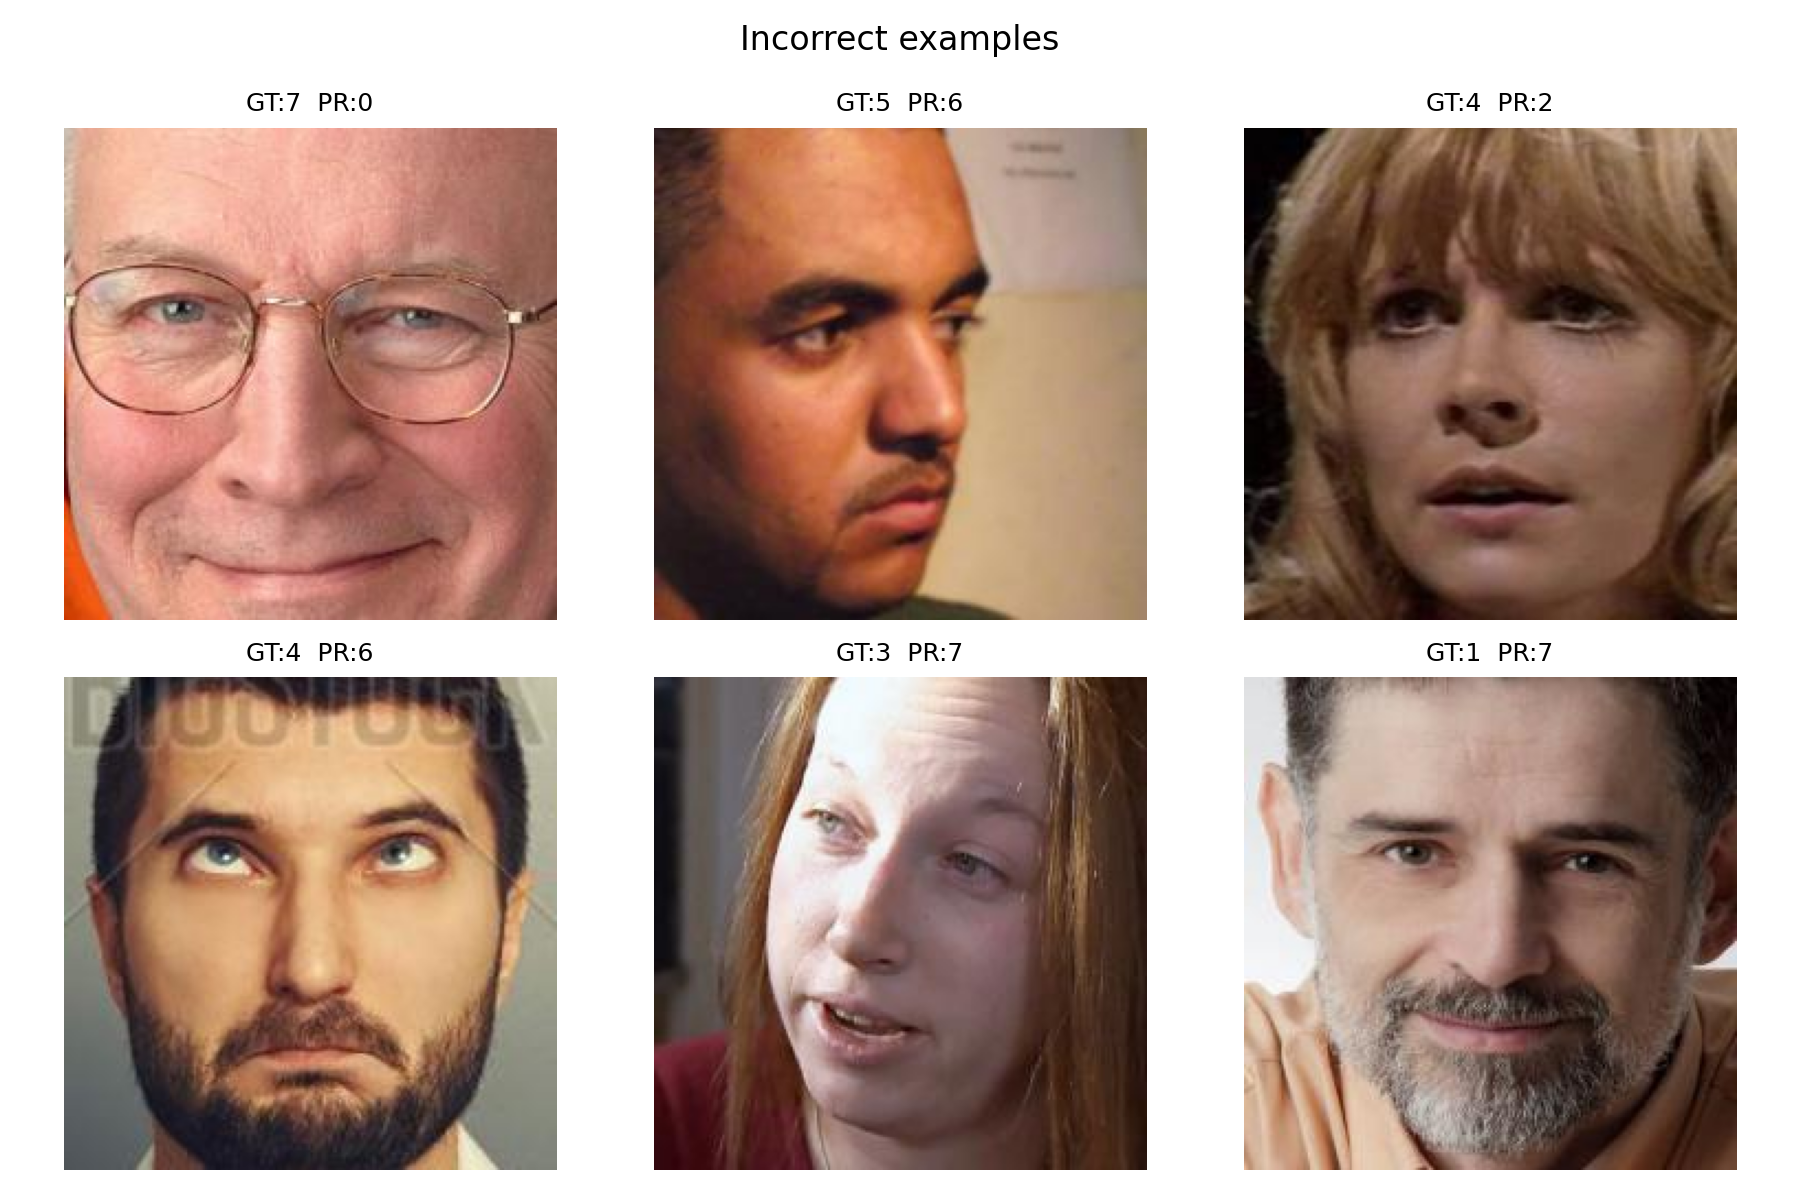

In [7]:
from pathlib import Path
import os, sys, subprocess, json
from IPython.display import Image, display

# 1) Detect project ROOT (folder that has both 'src/' and 'scripts/')
ROOT = Path.cwd()
for cand in [ROOT, ROOT.parent, ROOT.parent.parent]:
    if (cand/'src').exists() and (cand/'scripts').exists():
        ROOT = cand
        break
print("Project ROOT:", ROOT)

# 2) Absolute paths
ckpt    = ROOT / 'outputs' / 'checkpoints' / 'resnet18_best.pt'
eval_py = ROOT / 'scripts' / 'eval_report.py'
outdir  = ROOT / 'reports' / 'figs' / 'resnet18'
print("ckpt exists:", ckpt.exists(), "→", ckpt)
print("eval exists:", eval_py.exists(), "→", eval_py)
outdir.mkdir(parents=True, exist_ok=True)

# 3) Ensure Python can import your project (PYTHONPATH)
env = os.environ.copy()
env['PYTHONPATH'] = str(ROOT) + os.pathsep + env.get('PYTHONPATH', '')

# 4) Run eval from ROOT (so it writes to ROOT/reports/figs/...)
cmd = [sys.executable, str(eval_py), '--backbone', 'resnet18', '--ckpt', str(ckpt)]
print("Running:", " ".join(cmd))
ret = subprocess.run(cmd, cwd=str(ROOT), env=env, capture_output=True, text=True)
print("Return code:", ret.returncode)
if ret.stdout: print("--- stdout ---\n", ret.stdout)
if ret.stderr: print("--- stderr ---\n", ret.stderr)

# 5) Read summary.json (with absolute path)
summary_path = outdir / 'summary.json'
if summary_path.exists():
    data = json.loads(summary_path.read_text(encoding='utf-8'))
    print("Loaded summary from:", summary_path)
    print(json.dumps(data, indent=2)[:2000])  # preview
else:
    print("summary.json still not found at:", summary_path)

# 6) Show a couple of figs inline
for f in ['confusion_matrix.png', 'examples_correct.png', 'examples_incorrect.png']:
    p = outdir / f
    if p.exists():
        display(Image(filename=str(p)))
